In [3]:
# ================================
# SETUP + IMPORTS
# ================================
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Força o notebook a rodar a partir da RAIZ do projeto
PROJECT_ROOT = Path("..").resolve()
os.chdir(PROJECT_ROOT)

DATA_PATH = PROJECT_ROOT / "data" / "revolut_reviews.csv"
CLEAN_PATH = PROJECT_ROOT / "data" / "revolut_reviews_clean.csv"

print("CWD:", Path.cwd())
print("CSV exists?", DATA_PATH.exists(), "|", DATA_PATH)

CWD: /
CSV exists? False | /data/revolut_reviews.csv


In [5]:
# ================================
# UPLOAD MANUAL DO CSV (COLAB)
# ================================
from google.colab import files
uploaded = files.upload()

Saving revolut_reviews.csv to revolut_reviews.csv


In [9]:
# ================================
# LOAD CSV (BRUTO)
# ================================
import pandas as pd

df_raw = pd.read_csv("revolut_reviews.csv")
df_raw.head()

,rating,review,date,likes,app_version
0,5,Good bank but kept trying to change my current...,2026-02-20 22:47:25,0,NaN
1,5,"great, easy to use.",2026-02-20 22:17:21,0,10.117
2,5,Good,2026-02-20 22:13:34,0,NaN
3,5,"I think it's a really handy app to have, I was...",2026-02-20 22:12:17,0,10.117
4,1,I was doing an order before midnight to avoid ...,2026-02-20 21:48:46,0,10.117


In [10]:
# ================================
# CLEANING ROBUSTO + SAVE CLEAN
# ================================
import re

df = df_raw.copy()
df.columns = [c.strip().lower() for c in df.columns]

# achar coluna de rating
rating_candidates = ["rating", "stars", "score"]
rating_col = next((c for c in rating_candidates if c in df.columns), None)
if rating_col is None:
    raise Exception(f"Nenhuma coluna de rating encontrada. Colunas: {df.columns.tolist()}")

# achar coluna de texto
text_candidates = ["review_text", "review", "text", "content", "comment", "body"]
text_col = next((c for c in text_candidates if c in df.columns), None)
if text_col is None:
    obj_cols = [c for c in df.columns if df[c].dtype == "object"]
    if not obj_cols:
        raise Exception("Nenhuma coluna de texto encontrada (object).")
    text_col = obj_cols[0]

df["rating"] = pd.to_numeric(df[rating_col], errors="coerce")
df["review_text"] = df[text_col].astype(str).str.strip().str.lower()
df = df.dropna(subset=["rating", "review_text"])
df["rating"] = df["rating"].astype(int)

df["review_len"] = df["review_text"].str.len()
df["churn_risk"] = (df["rating"] <= 2).astype(int)

df_clean = df[["rating", "review_text", "review_len", "churn_risk"]].copy()

df_clean.to_csv("revolut_reviews_clean.csv", index=False)

df_clean.head(), df_clean.shape

(   rating                                        review_text  review_len  \
 0       5  good bank but kept trying to change my current...         259   
 1       5                                great, easy to use.          19   
 2       5                                               good           4   
 3       5  i think it's a really handy app to have, i was...         179   
 4       1  i was doing an order before midnight to avoid ...         227   
 
    churn_risk  
 0           0  
 1           0  
 2           0  
 3           0  
 4           1  ,
 (1200, 4))

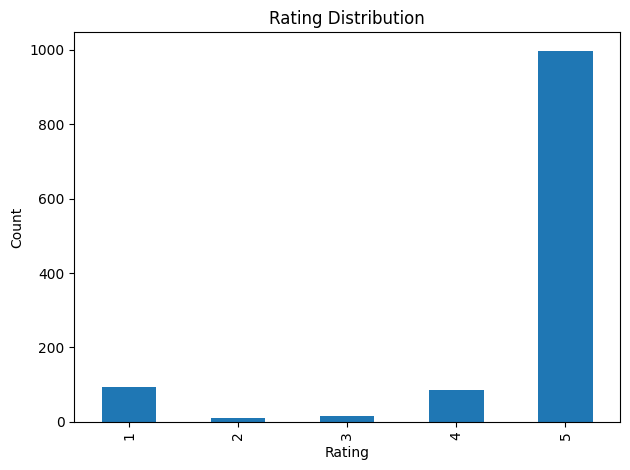

In [11]:
# ================================
# EDA - DISTRIBUIÇÃO DE RATINGS
# ================================
import matplotlib.pyplot as plt

plt.figure()
df_clean["rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.show()